# Discrétisation d'une EDS: erreur forte

Soit $(x_t)_{t \in [0,T]}$ solution d'une EDS 
\begin{equation*}
    \operatorname{d}\! x_t = b(x_t) \operatorname{d}\! t + \sigma(x_t) \operatorname{d}\! W_t, \quad x_0 \in \mathbf{R^d}.
\end{equation*}
On se donne des instants de discrétisation $0=t_0 < t_1 < \dots < t_N = T$ et dans la suite on spécifie la grille homogène $t_n = n \frac{T}{N} = n h$ avec $h = \frac{T}{N}$ appelé le pas de discrétisation.

**Schéma d'Euler**   
On rappelle le schéma d'Euler pour une diffusion:
\begin{equation*}
    X_{t_{n+1}} = X_{t_n} + b(X_{t_n}) h + \sigma(X_{t_n}) \sqrt{h} G_{n+1}, \quad X_0 = x_0.
\end{equation*}
où dans toute la suite $(G_1,\dots,G_N)$ est un vecteur Gaussien centré réduit (composantes indépendantes). La loi de $\sqrt{h} G_{n+1}$ est celle de l'accroissement $W_{t_{n+1}} - W_{t_n}$.

**Schéma de Milstein**  
Avec les mêmes notations que précédemment on définit le schéma de Milstein pour une diffusion (en dimension 1):
\begin{equation*}
    X_{t_{n+1}} = X_{t_n} + b(X_{t_n}) h + \sigma(X_{t_n}) \sqrt{h} G_{n+1} + \frac{1}{2} (\sigma \sigma')(X_{t_n})(G_{n+1}^2 - 1) h.
\end{equation*}


On peut aussi utiliser la version équivalente de Newton (sans $\sigma'$) 
\begin{align*}
    &X_{t_{n+1}} = X_{t_n} + b(X_{t_n}) h  - \sigma(X_{t_n}) \sqrt{h} + \tilde \sigma_{n+1} \sqrt{h} (G_{n+1} + 1), \\ 
    &\text{avec } \tilde \sigma_{n+1} = \sigma\left(X_{t_n} + \frac{1}{2} \sigma(X_{t_n}) \sqrt{h} \big(G_{n+1} - 1\big) \right).
\end{align*}

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()

## Diffusion Black-Scholes comme "benchmark"

L'équation différentielle stochastique (EDS) est donnée par 
\begin{equation*}
    \operatorname{d}\! x_t = r x_t \operatorname{d}\! t + \sigma x_t \operatorname{d}\! W_t, \quad x_0 > 0
\end{equation*}

**Rappel:** Pour Black-Scholes on connaît la vraie solution 
\begin{equation*}
    \forall t \in [0,T], \quad x_t = x_0 e^{\left(r - \frac{\sigma^2}{2} \right) t + \sigma W_t}.
\end{equation*}

### Classe `BlackScholes`

Ecrire une classe `BlackScholes` pour manipuler le processus de Black-Scholes en dimension 1, dont le constructeur prend 4 paramètres $x_0 \in \mathbf{R}$, $r \in \mathbf{R}$, $\sigma \in \mathbf{R}$ et $T > 0$ et qui possède 3 méthodes: 
- `paths_exact(self, dW)`
- `paths_euler(self, dW)`
- `paths_milstein(self, dW)`
où `dW` représente les accroissements des mouvements browniens utilisés pour construire les trajectoires de $(x_{t_n})_{n=0,\dots,N}$ (et ses schémas). Plus précisément `dW` est un `np.array` de shape $(N, M)$ avec $N$ le nombre de points utilisés pour discrétiser $[0,T]$ (ie $h = T/N$) et $M$ le nombre de trajectoires browniennes.

Un appel possible est 
```
X = BlackScholes(x0=100, r=0.04, sigma=0.1, T=1)
N, M = 10, 100
dW = np.sqrt(X.T / N) * rng.standard_normal((N, M))
X.paths_exact(dW)
```

In [8]:
class BlackScholes(object):
    def __init__(self, x0, r, sigma, T):
        self.x0 = x0
        self.r = r
        self.sigma = sigma
        self.T = T
    
    def paths_exact(self, dW):
        N, M = dW.shape[0], dW.shape[1]
        X = np.zeros((N, M))
        X[0] = self.x0
        for i in range(1, N):
            dt = self.T / N
            X[i] = X[i-1] * np.exp((self.r - 0.5 * self.sigma**2) * dt + self.sigma * dW[i-1])
        return X

    def paths_euler(self, dW):
        N, M = dW.shape[0], dW.shape[1]
        X = np.zeros((N, M))
        X[0] = self.x0
        for i in range(1, N):
            dt = self.T / N
            X[i] = X[i-1] + self.r * X[i-1] * dt + self.sigma * X[i-1] * dW[i-1]
        return X
    
    def paths_milstein(self, dW):
        N, M = dW.shape[0], dW.shape[1]
        X = np.zeros((N, M))
        X[0] = self.x0
        for i in range(1, N):
            dt = self.T / N
            X[i] = X[i-1] + self.r * X[i-1] * dt + self.sigma * X[i-1] * dW[i-1] + 0.5 * self.sigma**2 * X[i-1] * (dW[i-1]**2 - dt)
        return X

In [5]:
X = BlackScholes(x0=100, r=0.04, sigma=0.1, T=1)
N, M = 10, 100
dW = np.sqrt(X.T / N) * rng.standard_normal((N, M))
X.paths_exact(dW)

array([[100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.        , 100.        ,
        100.        , 100.        , 100.

### Question: représentation de trajectoires

Tracer sur un même graphe $M=15$ trajectoires de $(x_t)_{t \in [0,T]}$ avec $T=5$ aux instants $t_n = n \frac{T}{N}$ avec $N = 10$, et les schémas d'Euler et de Milstein associés. Les schémas doivent être construits en utilisant les mêmes accroissements browniens que $(x_t)_{t \in [0,1]}$. 

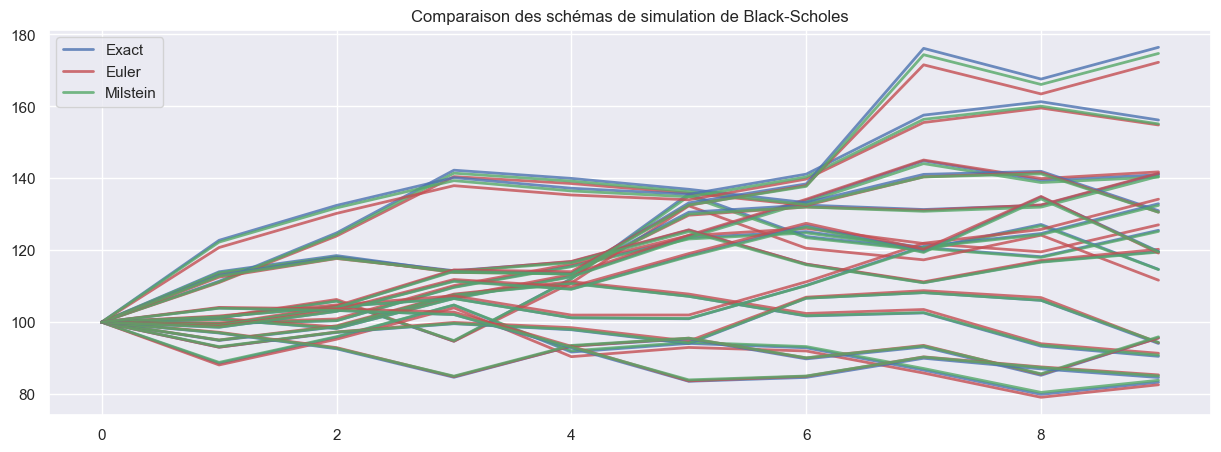

In [ ]:
N, M = 10, 15
X = BlackScholes(x0=100, r=0.04, sigma=0.1, T=5)
dW = np.sqrt(X.T / N) * rng.standard_normal((N, M))

plt.figure(figsize=(15,5))
for i in range(15):
    plt.plot(X.paths_exact(dW)[:, i], 'b-', alpha=0.8, linewidth=2, label='Exact' if i==0 else "")
    plt.plot(X.paths_euler(dW)[:, i], 'r-', alpha=0.8, linewidth=2, label='Euler' if i==0 else "")
    plt.plot(X.paths_milstein(dW)[:, i], 'g-', alpha=0.8, linewidth=2, label='Milstein' if i==0 else "")
    plt.legend()
    plt.title('Comparaison des schémas de simulation de Black-Scholes')

Text(0.5, 1.0, 'Comparaison des schémas de simulation de Black-Scholes : Euler vs Milstein')

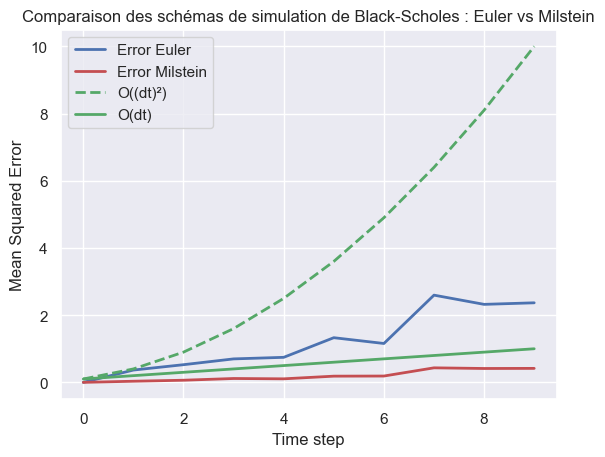

In [36]:

plt.plot(np.mean((X.paths_exact(dW)[:, :] - X.paths_euler(dW)[:, :])**2, axis=1), 'b-', linewidth=2, label='Error Euler')
plt.plot(np.mean((X.paths_exact(dW)[:, :] - X.paths_milstein(dW)[:, :])**2, axis=1), 'r-', linewidth=2, label='Error Milstein')
plt.plot(np.power(np.arange(1, N+1), 2) * 0.1, 'g--', linewidth=2, label='O((dt)²)')
plt.plot(np.arange(1, N+1) * 0.1, 'g', linewidth=2, label='O(dt)')
plt.ylabel('Mean Squared Error')
plt.xlabel('Time step')
plt.legend()
plt.title('Comparaison des schémas de simulation de Black-Scholes : Euler vs Milstein')

## Erreur forte

On dit que le schéma est d'erreur forte $\mathbf{L}^p$, $p > 1$ d'ordre $\beta > 0$ si 
\begin{equation*}
    \left\lVert \sup_{t \in [0,T]} |x_{t} - X^h_{t}|\right\rVert_p = \mathcal{O}(h^\beta) 
\end{equation*}
ou encore 
\begin{equation*}
    \left\lVert \sup_{k \in \{0,\dots,N\}} |x_{t_k} - X^h_{t_k}|\right\rVert_p = \mathcal{O}(h^\beta) 
\end{equation*}

- Schéma d'Euler: erreur forte d'ordre $\beta = \frac{1}{2}$ dans tout $\mathbf{L}^p$ ($p > 1$).
- Schéma de Milstein: erreur forte d'ordre $\beta = 1$ dans tout $\mathbf{L}^p$ ($p > 1$) (dim 1...).


**Attention:** Il faut calculer $\sup_k |x_{t_k} - X^h_{t_k}|$ sur le même événement $\omega$ _i.e._ la même trajectoire Brownienne $(W_t)_{t \in  [0,T]}$.

### Question: fonction `strong_error`

Ecrire une fonction `strong_error` de prototype `strong_error(sde, scheme, N, M = 10000)`
où 
- `sde` est un objet de classe `BlackScholes`
- `scheme` est une chaine de caractère qui vaut `"Euler"` ou `"Milstein"`

qui renvoie l'erreur $L^2$ pour le schéma de discrétisation `scheme` et son intervalle de confiance à 95%. 

In [93]:
def strong_error(sde : BlackScholes, scheme : str, N : int, M : int, power : float = 2.0):
    dW = np.sqrt(sde.T / N) * rng.standard_normal((N, M))
    X_exact = sde.paths_exact(dW)
    if scheme == 'euler':
        X_approx = sde.paths_euler(dW)
    elif scheme == 'milstein':
        X_approx = sde.paths_milstein(dW)
    else:
        raise ValueError("Scheme must be either 'euler' or 'milstein'")
    error = np.max((X_exact - X_approx)**power, axis=0)
    I_M = np.mean(error)
    confident_interval = 1.96 * np.std(error) / np.sqrt(M)
    return np.sqrt(I_M), np.sqrt(I_M - confident_interval), np.sqrt(I_M + confident_interval)

### Question: illustration 

Tracer l'écolution de l'erreur forte du schéma d'Euler et celle du schéma de Milstein sur un même graphe en fonction de $N$. On prendra par exemple $N = 2, 4, 8, 16, \dots$

Text(0, 0.5, 'Strong Error')

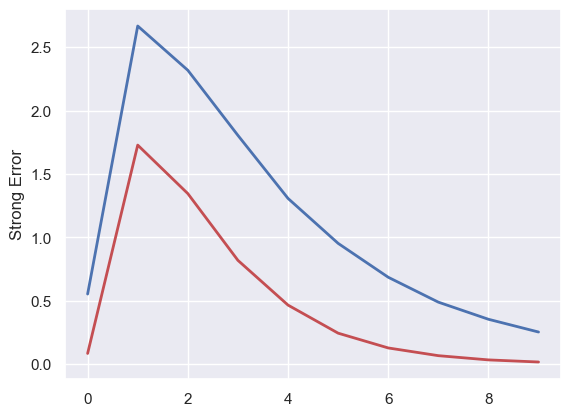

In [97]:
euler_error, euler_min, euler_max = strong_error(X, 'euler', N=100, M=1000)
milstein_error, milstein_min, milstein_max = strong_error(X, 'milstein', N=100, M=1000)

for i in range(1, 10):
    N = 2**i
    euler_err, euler_min_i, euler_max_i = strong_error(X, 'euler', N=N, M=10000)
    milstein_err, milstein_min_i, milstein_max_i = strong_error(X, 'milstein', N=N, M=10000)
    euler_error = np.append(euler_error, euler_err)
    euler_min = np.append(euler_min, euler_min_i)
    euler_max = np.append(euler_max, euler_max_i)
    milstein_error = np.append(milstein_error, milstein_err)
    milstein_min = np.append(milstein_min, milstein_min_i)
    milstein_max = np.append(milstein_max, milstein_max_i)

plt.plot(euler_error, 'b-', linewidth=2, label='Error Euler')
plt.plot(milstein_error, 'r-', linewidth=2, label='Error Milstein')
plt.ylabel('Strong Error')


### Question: Vérification des ordres de convergence

Faire une régression linéaire pour vérifier que l'ordre de convergence est $\beta = \frac{1}{2}$ pour le schéma d'Euler et $\beta = 1$ pour le schéma de Milstein.

## Erreur forte approchée
Comment estimer l'erreur forte d'un schéma sans connaître la vraie solution ? 

- Si $\left\lVert \sup_k |x_{t_k} - X^h_{t_k}| \right\rVert_p \to 0$ alors 
\begin{equation*}
    \left\lVert \sup_k |x_{t_k} - X^h_{t_k}| \right\rVert_p = \mathcal{O}(h^\beta)
    \quad \Longleftrightarrow \quad 
    \left\lVert \sup_k |X^h_{t_k} - X^{h/2}_{t_{2k}}| \right\rVert_p = \mathcal{O}(h^\beta) 
\end{equation*}

Il faut donc construire les schémas $(X^h_{kh})_{k=0,\dots,N}$ et $(X^{h/2}_{\frac{kh}{2}})_{k=0,\dots,2N}$ en _utilisant_ la même trajectoire brownienne... 

On fera de même pour mettre en oeuvre l'extrapolation de Richardson-Romberg qui permet de gagner un ordre pour l'erreur faible.

### Question: fonction `strong_error_app`

Ecrire une fonction similaire à `strong_error` pour qui estime l'erreur forte dans $\mathbf{L}^2$ sans utiliser d'appel à `sde.paths_exact`.

In [101]:
def strong_error_app(sde : BlackScholes, scheme : str, N : int, M : int, power : float = 2.0):
    dW_fine = np.sqrt(sde.T / N) * rng.standard_normal((N, M))
    dW_coarse = dW_fine[::2, : ] + dW_fine[1::2, :]
    if scheme == 'euler':
        X_approx_fine = sde.paths_euler(dW_fine)
        X_approx_coarse = sde.paths_euler(dW_coarse)
    elif scheme == 'milstein':
        X_approx_fine = sde.paths_milstein(dW_fine)
        X_approx_coarse = sde.paths_milstein(dW_coarse)
    else:
        raise ValueError("Scheme must be either 'euler' or 'milstein'")
    error = X_approx_fine[::2, : ] - X_approx_coarse
    E = np.max(np.abs(error)**power, axis=0)
    I_M = np.mean(E)
    confident_interval = 1.96 * np.std(E) / np.sqrt(M)
    return np.sqrt(I_M), np.sqrt(I_M - confident_interval), np.sqrt(I_M + confident_interval)
    

### Question: illustration et calcul de $\beta$

Illustrer la décroissance de l'erreur forte pour les 2 schémas et calculer le coefficient $\beta$ par une régression linéaire. 

Text(0, 0.5, 'Strong Error')

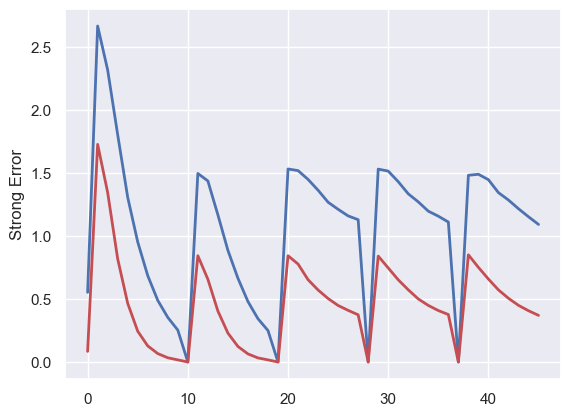

In [105]:
for i in range(1, 10):
    N = 2 * i
    euler_err, euler_min_i, euler_max_i = strong_error_app(X, 'euler', N=N, M=10000)
    milstein_err, milstein_min_i, milstein_max_i = strong_error_app(X, 'milstein', N=N, M=10000)
    euler_error = np.append(euler_error, euler_err)
    euler_min = np.append(euler_min, euler_min_i)
    euler_max = np.append(euler_max, euler_max_i)
    milstein_error = np.append(milstein_error, milstein_err)
    milstein_min = np.append(milstein_min, milstein_min_i)
    milstein_max = np.append(milstein_max, milstein_max_i)

plt.plot(euler_error, 'b-', linewidth=2, label='Error Euler')
plt.plot(milstein_error, 'r-', linewidth=2, label='Error Milstein')
plt.ylabel('Strong Error')